# Problem Set 4

In [309]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math as m
from matplotlib import ticker

## 3.5

### Pre

True
True


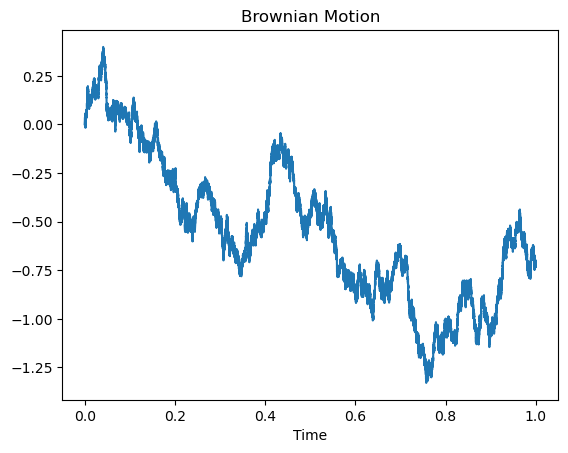

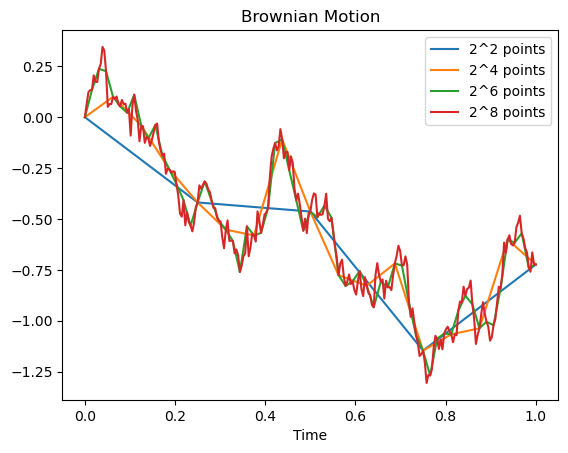

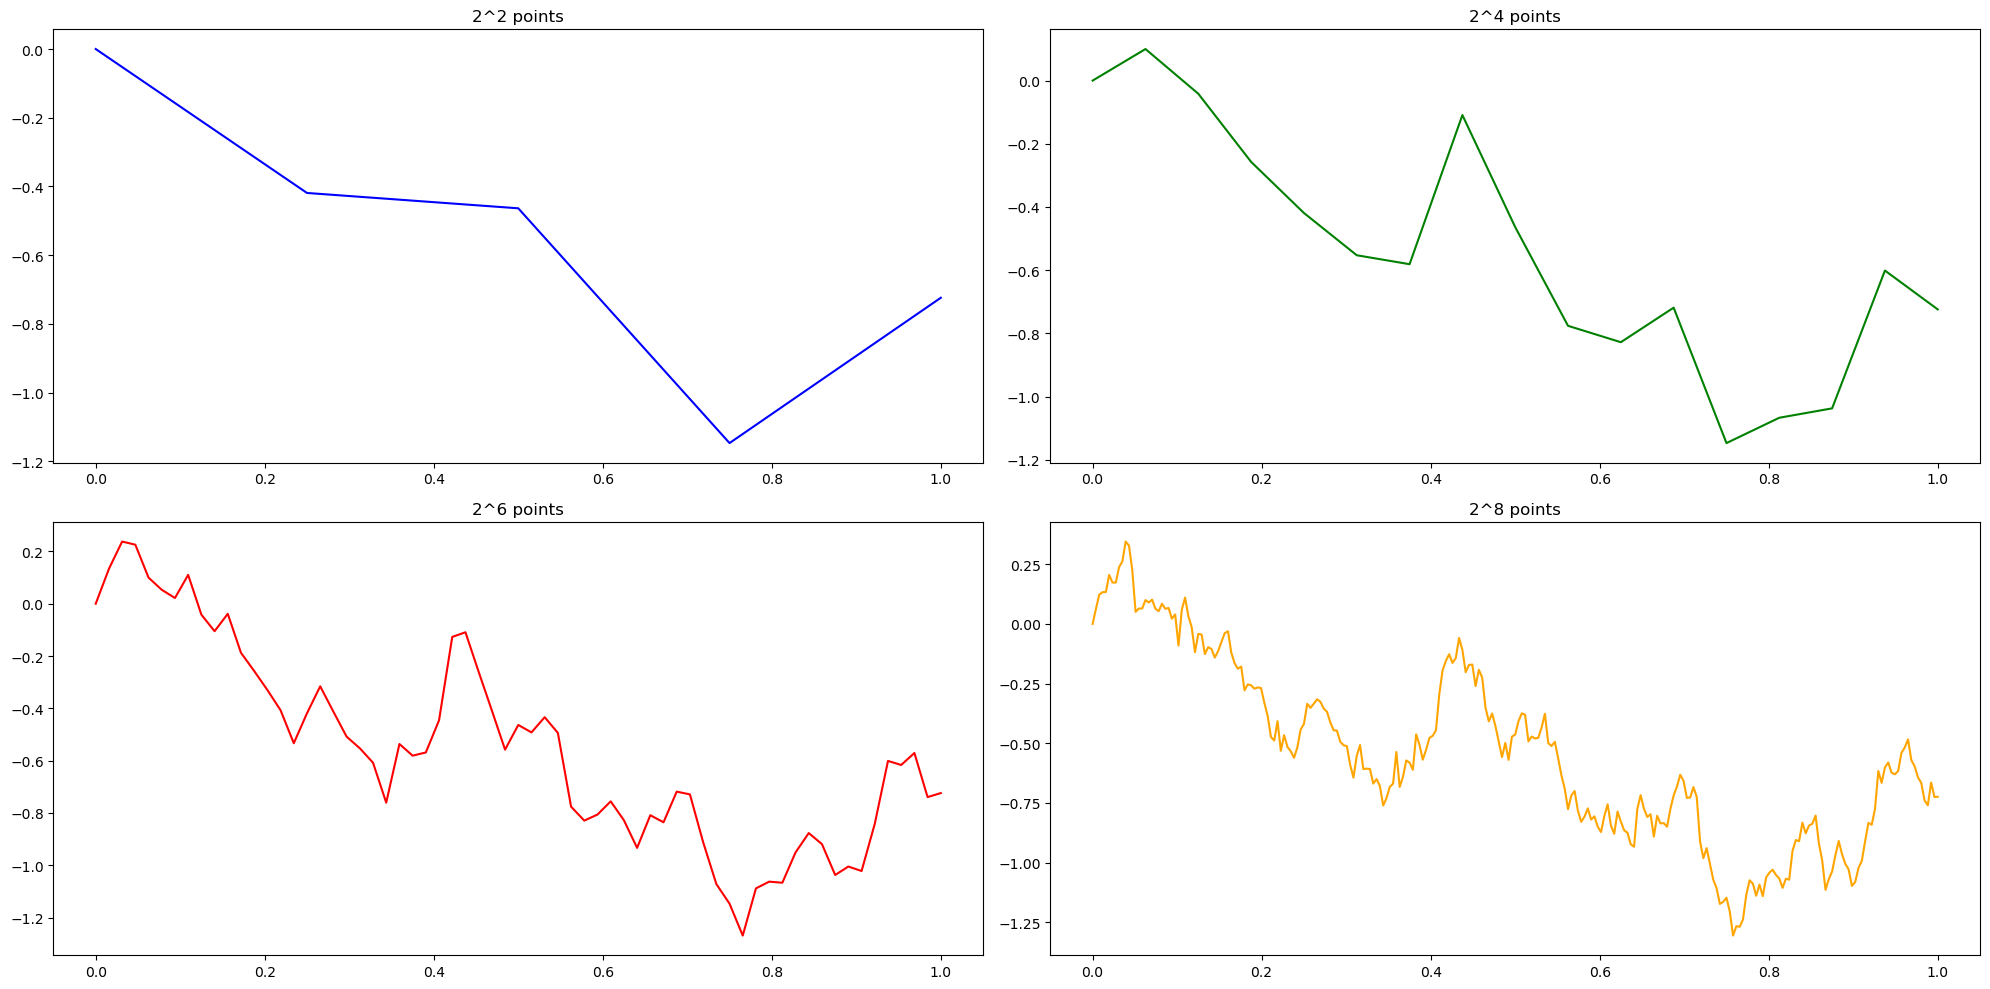

In [310]:
n = 20
spacing = np.linspace(0, 1, 2**n + 1, endpoint=True)

dt = spacing[1] - spacing[0]

print(dt == 2**(-1 * n))

diff = np.random.normal(loc = 0, scale = m.sqrt(dt), size = 2**n)

sample = np.append(np.array([0]) , diff)

BM = np.cumsum(sample)

print(len(spacing) == len(BM))

fig,ax = plt.subplots()
ax.plot(spacing,BM,alpha = 1)
ax.set_title("Brownian Motion")
ax.set_xlabel("Time")
plt.show()

for i in [2,4,6,8]:
    index = len(diff) * np.linspace(start=0,stop=1,num=2**i + 1)
    values = BM[index.astype(int)]
    x_axis = np.linspace(0, 1, len(values))
    plt.plot(x_axis, values,alpha = 1, label=f"2^{i} points")
plt.title("Brownian Motion")
plt.xlabel("Time")
plt.legend()
plt.show()


fig,((ax1,ax2),(ax3,ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(20,10))

index = len(diff) * np.linspace(start=0,stop=1,num=2**2 + 1)
values = BM[index.astype(int)]

ax1.plot(np.linspace(0, 1, len(values)),values, color='blue')
ax1.set_title("2^2 points")

index = len(diff) * np.linspace(start=0,stop=1,num=2**4 + 1)
values = BM[index.astype(int)]

ax2.plot(np.linspace(0, 1, len(values)),values, color='green')
ax2.set_title("2^4 points")

index = len(diff) * np.linspace(start=0,stop=1,num=2**6 + 1)
values = BM[index.astype(int)]

ax3.plot(np.linspace(0, 1, len(values)),values, color='red')
ax3.set_title("2^6 points")

index = len(diff) * np.linspace(start=0,stop=1,num=2**8 + 1)
values = BM[index.astype(int)]

ax4.plot(np.linspace(0, 1, len(values)),values, color='orange')
ax4.set_title("2^8 points")


plt.tight_layout()
plt.show()


### a

In [311]:
variation = dict()
quadratic = dict()
for i in range(1,n+1):
    index = len(diff) * np.linspace(start=0,stop=1,num=2**i + 1)
    #print(index)
    values = BM[index.astype(int)]
    variation[i] = np.sum(np.abs(np.diff(values)))
    #print(len(np.diff(values)))
    quadratic[i] = np.sum(np.diff(values) ** 2)

df = pd.DataFrame.from_dict(variation, orient='index', columns=['Variation'])
df = df.rename_axis('n', axis=1)
df
    
    
    

n,Variation
1,0.724099
2,1.570221
3,1.805010
4,3.178244
5,4.272597
6,6.095446
7,9.635189
8,12.414240
9,17.459014
10,24.956837


### b

In [312]:
df = pd.DataFrame.from_dict(quadratic, orient='index', columns=['Quadratic Variation'])
df = df.rename_axis('n', axis=1)
df

n,Quadratic Variation
1,0.282815
2,0.823697
3,0.528955
4,0.978291
5,0.963770
6,0.867662
7,1.071617
8,0.945199
9,0.951763
10,0.955642


### c

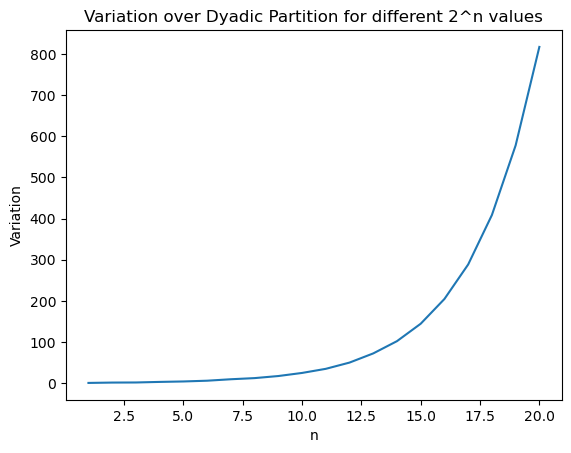

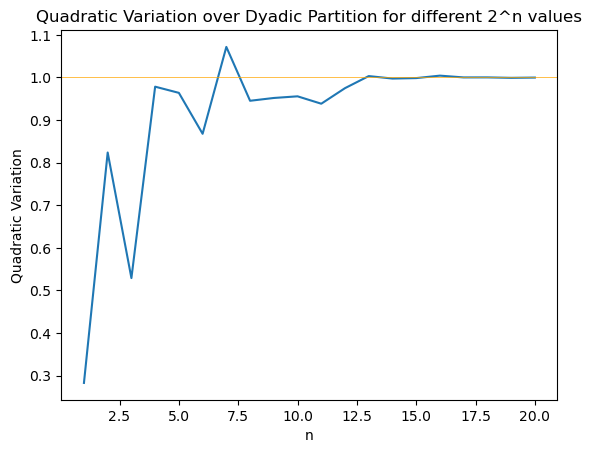

In [313]:
plt.plot(list(variation.keys()), list(variation.values()))
plt.title("Variation over Dyadic Partition for different 2^n values")
plt.xlabel("n")
plt.ylabel("Variation")
plt.show()


plt.plot(list(quadratic.keys()), list(quadratic.values()))
plt.title("Quadratic Variation over Dyadic Partition for different 2^n values")
plt.xlabel("n")
plt.ylabel("Quadratic Variation")
plt.axhline(y=1, color='orange', linewidth=0.5)
plt.show()

From the graphs of the above variation and quadratic variation, we can a couple of things. For variation, $\sum_{j=1}^{2^n - 1} |B_{t_{j+1}} - B_{t_{j}}|$ we can see that the function is very smooth, but $\lim_{n \to \infty} \sum_{j=1}^{2^n - 1} |B_{t_{j+1}} - B_{t_{j}}| = \infty$. As for quadratic variation, $\sum_{j=1}^{2^n - 1} (B_{t_{j+1}} - B_{t_{j}})^2$, the function is not as smooth, it is more jagged. But $\lim_{n \to \infty} \sum_{j=1}^{2^n - 1} (B_{t_{j+1}} - B_{t_{j}})^2 = t = 1$ This shows that $\langle B \rangle_{t} = \lim_{n \to \infty} \sum_{j=1}^{2^n - 1} (B_{t_{j+1}} - B_{t_{j}})^2 = t \text{ almost surely}$

## 3.6

In [314]:
def Lamda(u):
    u = np.asarray(u)
    out = np.zeros_like(u, dtype=float)
    m1 = (0 <= u) & (u <= 0.5)
    m2 = (0.5 < u) & (u <= 1.0)
    out[m1] = u[m1]
    out[m2] = 1.0 - u[m2]
    return out

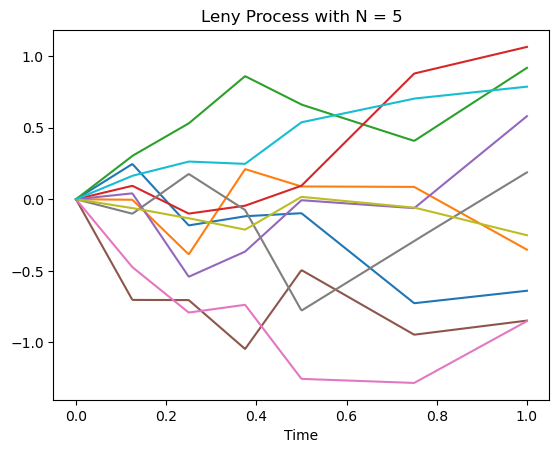

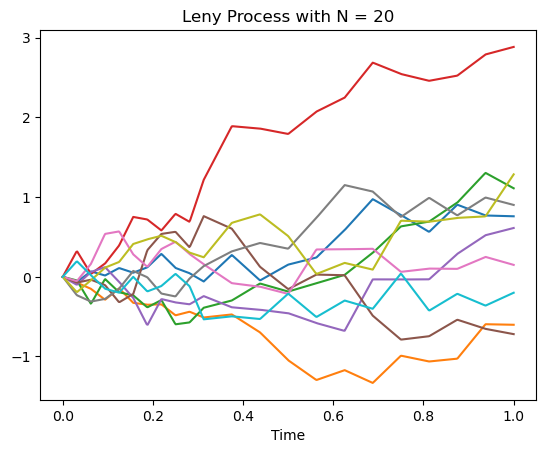

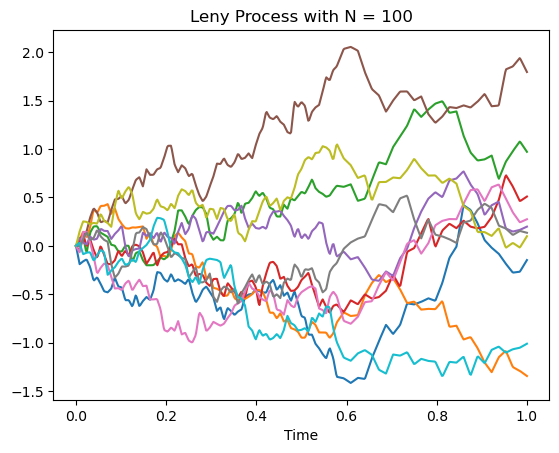

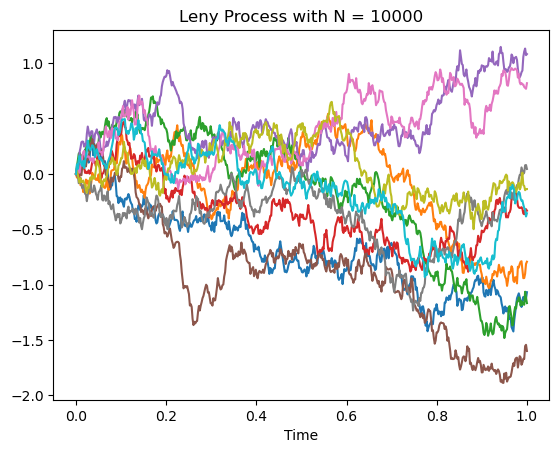

In [315]:
def Leny(N):
    spacing = np.linspace(0,1,500)
    start = spacing * np.random.normal(0,1)
    change = np.zeros(shape=len(spacing))
    for i in range(1,N+1):
        j = m.floor(m.log(i,2))
        k = i - (2**j)
        change += 2**(-j/2) * Lamda((2**j) * spacing - k) * np.random.normal(loc = 0, scale= 1)
    return start + change

for i in [5,20,100,10000]:
    paths = []  
    for _ in range(10):
        paths.append(Leny(i))
    plt.plot(np.linspace(0,1,500), np.asarray(paths).T)
    plt.title(f"Leny Process with N = {i}")
    plt.xlabel("Time")
    plt.show()